# Лабораторная работа № 4. Моделирование с помощью ARIMA-инструментов

**Данные:** Мировые продажи полупроводников (WSTS), январь 2020 — декабрь 2024  
**Результаты предыдущих работ:**
- **ЛР №1:** тип процесса DS(I₁), d = 1
- **ЛР №2:** структурный излом в декабре 2022 (t₀ = 36), тип DS(I₁) со структурным скачком
- **ЛР №3:** лучший метод удаления сезонности — **фиктивные переменные** (T = 12)

# 1. Цель работы
Смоделировать показатель с помощью ARIMA-инструментов для построения качественного прогноза.

## 1.1 Задачи
1. Определить зависимую переменную с учётом структурного излома из ЛР №2.
2. Включить фиктивные переменные излома как экзогенные регрессоры (ARIMAX).
3. Провести идентификацию порядков p и q по скорректированным остаткам.
4. Оценить кандидатные ARIMAX-модели и выбрать лучшую.
5. Провести диагностику итоговой модели.

# 2. Теоретические сведения

## 2.1 Почему нужен ARIMAX, а не чистый ARIMA
В ЛР №1 получен тип DS(I₁). В ЛР №2 обнаружен **структурный излом в декабре 2022**: рынок полупроводников резко упал после пандемийного бума. Этот излом порождает в первых разностях **один аномально большой выброс** и нарушает предположение о нормальности остатков (JB-тест и DW вышли за пределы нормы).

Решение по методичке (ЛР №2): включить фиктивные переменные **ds** и **ds1** в уравнение модели. Для ARIMA(p,1,q) экзогенные переменные берутся **в первых разностях** (как и зависимая переменная):

$$\Delta y_t = c + \beta_1 \Delta ds_t + \beta_2 \Delta ds1_t + \text{ARMA}(p,q) + \varepsilon_t$$

- $\Delta ds_t$ — **импульсная переменная**: 1 в момент излома (декабрь 2022), 0 иначе
- $\Delta ds1_t$ — **ступенчатая переменная**: 0 до излома, 1 после (нарастающий счётчик)

## 2.2 Идентификация порядков
После вычитания эффекта излома из Δy_t смотрим на ACF/PACF очищенных остатков.

# 3. Практическая часть
## 3.1 Загрузка данных и сезонная корректировка (ЛР №3)

In [1]:
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display
from scipy import stats as scipy_stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf as acf_func, pacf as pacf_func, adfuller
warnings.filterwarnings("ignore")

fmt = mticker.FuncFormatter(lambda x, _: f'{x:,.0f}')

wsts_data = {
    (2020,1):35123,(2020,2):33456,(2020,3):35678,(2020,4):35901,
    (2020,5):36456,(2020,6):37890,(2020,7):39123,(2020,8):39789,
    (2020,9):38456,(2020,10):39567,(2020,11):40123,(2020,12):40567,
    (2021,1):40234,(2021,2):38901,(2021,3):41567,(2021,4):43890,
    (2021,5):44234,(2021,6):45678,(2021,7):47123,(2021,8):47890,
    (2021,9):46234,(2021,10):47567,(2021,11):48123,(2021,12):47456,
    (2022,1):49234,(2022,2):46789,(2022,3):49890,(2022,4):51234,
    (2022,5):51678,(2022,6):52123,(2022,7):51567,(2022,8):50890,
    (2022,9):47234,(2022,10):48567,(2022,11):47890,(2022,12):45678,
    (2023,1):40234,(2023,2):38456,(2023,3):40890,(2023,4):42123,
    (2023,5):42567,(2023,6):43890,(2023,7):45234,(2023,8):45678,
    (2023,9):44123,(2023,10):45456,(2023,11):46123,(2023,12):46789,
    (2024,1):46567,(2024,2):44890,(2024,3):48123,(2024,4):49567,
    (2024,5):50123,(2024,6):51456,(2024,7):52890,(2024,8):53234,
    (2024,9):51789,(2024,10):53123,(2024,11):53567,(2024,12):52890,
}
index = pd.date_range(start='2020-01', periods=60, freq='MS')
ts = pd.Series([wsts_data[(d.year, d.month)] for d in index],
               index=index, name='WSTS', dtype=float)
T = 12
t_num = pd.Series(np.arange(1, 61), index=ts.index, name='t')

phase_series = pd.Series(ts.index.month, index=ts.index)
all_dummies  = pd.get_dummies(phase_series, prefix='D', dtype=float)
dummies_11   = all_dummies.drop(columns=['D_12'])  # база = декабрь

dummy_model  = sm.OLS(ts, sm.add_constant(dummies_11)).fit()
seas_component = dummy_model.fittedvalues - dummy_model.params['const']
ts_adj = (ts - seas_component).rename('WSTS_adj')

print(f"Исходный ряд:       n={len(ts)}, среднее={ts.mean():,.0f}")
print(f"Сезонно скорр.:     n={len(ts_adj)}, среднее={ts_adj.mean():,.0f}")
print(f"R² сезонной модели: {dummy_model.rsquared:.4f}")

Исходный ряд:       n=60, среднее=45,226
Сезонно скорр.:     n=60, среднее=46,676
R² сезонной модели: 0.1616


## 3.2 Фиктивные переменные структурного излома (из ЛР №2)

Точка излома — **декабрь 2022**, порядковый номер наблюдения t₀ = 36.

Для ARIMAX с d = 1 экзогенные переменные также берутся **в первых разностях**:
- **Δds** — импульс: равен 1 только в момент первого дифференцирования излома
- **Δds1** — ступенька: 0 до излома, 1 начиная с него

In [2]:
t0_idx  = 36
t_arr   = np.arange(1, 61)

# ds  = 0 до t₀, 1 начиная с t₀  (ступенька уровня)
# ds1 = max(0, t - t₀)           (изменение наклона после излома)
ds_level  = pd.Series((t_arr >= t0_idx).astype(float), index=ts.index, name='ds')
ds_slope  = pd.Series(np.maximum(0, t_arr - t0_idx).astype(float), index=ts.index, name='ds1')

d_ds   = ds_level.diff().fillna(0).rename('d_ds')    # импульс в t₀
d_ds1  = ds_slope.diff().fillna(0).rename('d_ds1')   # ступенька 0→1 с t₀+1

preview = pd.DataFrame({
    't': t_arr,
    'ds': ds_level,
    'ds1': ds_slope,
    'Δds': d_ds,
    'Δds1': d_ds1,
    'ts_adj': ts_adj,
}).iloc[33:39]

print("Фиктивные переменные вблизи точки излома (t₀=36, декабрь 2022):")
display(preview.round(1))

Фиктивные переменные вблизи точки излома (t₀=36, декабрь 2022):


,t,ds,ds1,Δds,Δds1,ts_adj
2022-10-01,34,0.0,0.0,0.0,0.0,48387.0
2022-11-01,35,0.0,0.0,0.0,0.0,47400.8
2022-12-01,36,1.0,0.0,1.0,0.0,45678.0
2023-01-01,37,1.0,1.0,0.0,1.0,44631.6
2023-02-01,38,1.0,2.0,0.0,1.0,44633.6
2023-03-01,39,1.0,3.0,0.0,1.0,44336.4


## 3.3 Зависимая переменная и предварительный анализ Δy_t

Тип процесса DS(I₁) → **d = 1**, зависимая переменная — первые разности скорректированного ряда.

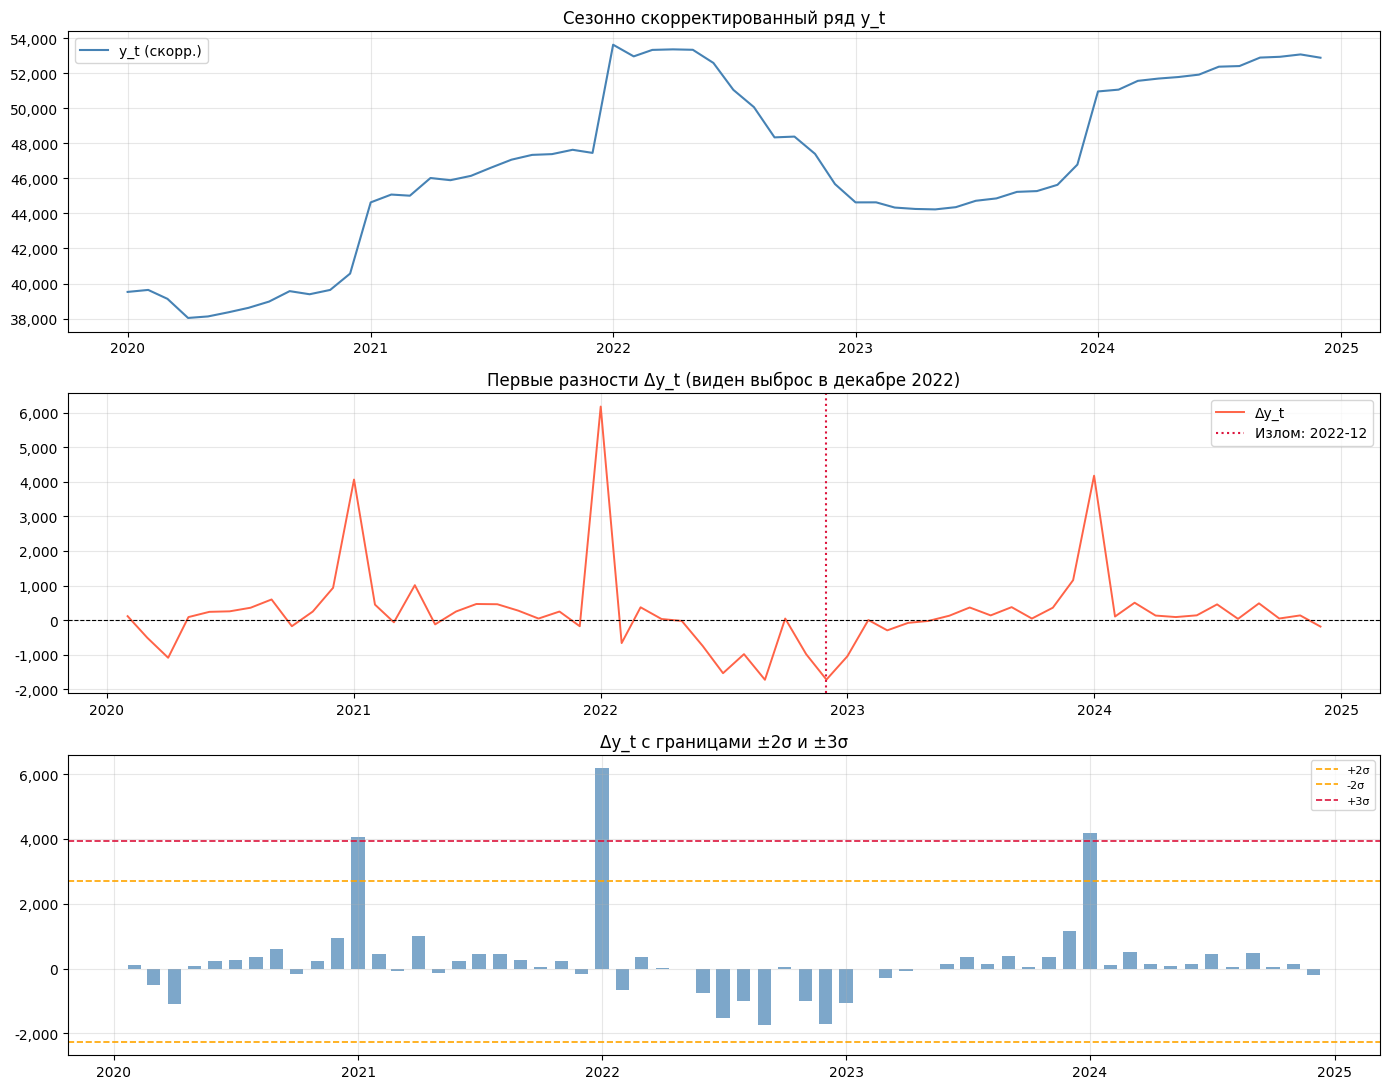

Среднее Δy: 226.6, σ: 1239.9
Выброс янв.2022: 6,176  (4.8σ)


In [3]:
dy = ts_adj.diff().dropna().rename('dy')

fig, axes = plt.subplots(3, 1, figsize=(14, 11))

axes[0].plot(ts_adj, color='steelblue', linewidth=1.5, label='y_t (скорр.)')
axes[0].set_title('Сезонно скорректированный ряд y_t', fontsize=12)
axes[0].yaxis.set_major_formatter(fmt); axes[0].grid(True, alpha=0.3); axes[0].legend()

axes[1].plot(dy, color='tomato', linewidth=1.4, label='Δy_t')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
# Выделить точку излома
break_dt = pd.Timestamp('2022-12-01')
axes[1].axvline(break_dt, color='crimson', linestyle=':', linewidth=1.5,
                label=f'Излом: {break_dt.strftime("%Y-%m")}')
axes[1].set_title('Первые разности Δy_t (виден выброс в декабре 2022)', fontsize=12)
axes[1].yaxis.set_major_formatter(fmt); axes[1].grid(True, alpha=0.3); axes[1].legend()

# Выброс аномален?
mu, sigma = dy.mean(), dy.std()
axes[2].bar(dy.index, dy.values, width=20, color='steelblue', alpha=0.7)
axes[2].axhline(mu + 2*sigma, color='orange', linestyle='--', linewidth=1.2, label='+2σ')
axes[2].axhline(mu - 2*sigma, color='orange', linestyle='--', linewidth=1.2, label='-2σ')
axes[2].axhline(mu + 3*sigma, color='crimson', linestyle='--', linewidth=1.2, label='+3σ')
axes[2].set_title('Δy_t с границами ±2σ и ±3σ', fontsize=12)
axes[2].yaxis.set_major_formatter(fmt); axes[2].grid(True, alpha=0.3); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Среднее Δy: {mu:.1f}, σ: {sigma:.1f}")
print(f"Выброс янв.2022: {dy.loc['2022-01-01']:,.0f}  ({(dy.loc['2022-01-01']-mu)/sigma:.1f}σ)")

## 3.4 Идентификация порядков p и q

**Проблема чистого ARIMA:** выброс в Δy_t (декабрь 2022 = −1954 млн.) искажает ACF/PACF и DW.

**Решение:** сначала регрессируем Δy_t на Δds и Δds1, получаем очищенные остатки, по ним определяем p и q.

In [4]:
exog_df  = pd.concat([d_ds, d_ds1], axis=1).loc[dy.index]
ols_pre  = sm.OLS(dy, sm.add_constant(exog_df)).fit()
dy_clean = pd.Series(ols_pre.resid, index=dy.index, name='dy_clean')

print("Предварительная OLS (Δy ~ Δds + Δds1):")
pre_df = pd.DataFrame({
    'Параметр'   : ols_pre.params.index,
    'Коэффициент': ols_pre.params.values.round(1),
    'p-value'    : ols_pre.pvalues.values.round(4),
    'Значим?'    : ['✓' if p < 0.05 else '✗' for p in ols_pre.pvalues],
})
display(pre_df)
print(f"\nDW очищенных остатков: {durbin_watson(dy_clean):.4f}")

Предварительная OLS (Δy ~ Δds + Δds1):


,Параметр,Коэффициент,p-value,Значим?
0,const,231.8,0.2780,✗
1,d_ds,-1954.6,0.1240,✗
2,d_ds1,68.7,0.8352,✗



DW очищенных остатков: 1.8356


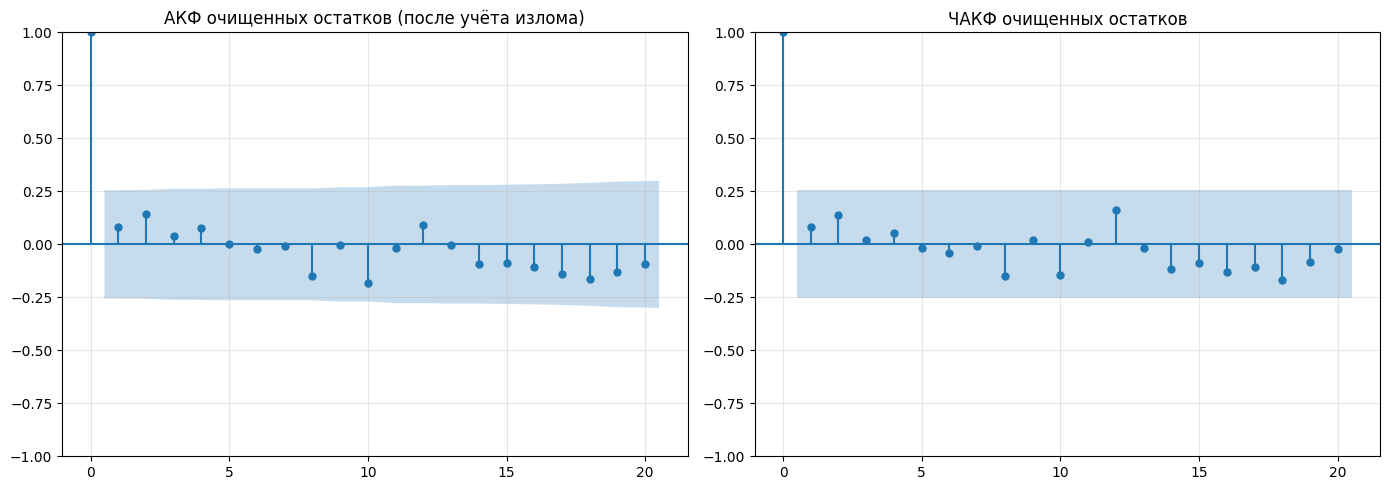

Граница значимости: ±0.2552


,Лаг,ACF,PACF,ACF зн.,PACF зн.
0,1,0.0807,0.0807,,
1,2,0.1444,0.1388,,
2,3,0.0390,0.0182,,
3,4,0.0756,0.0530,,
4,5,0.0019,-0.0150,,
5,6,-0.0203,-0.0386,,
6,7,-0.0078,-0.0056,,
7,8,-0.1510,-0.1505,,
8,9,-0.0052,0.0197,,
9,10,-0.1811,-0.1461,,


In [5]:
conf_bound = 1.96 / np.sqrt(len(dy_clean))
acf_vals   = acf_func(dy_clean, nlags=15, fft=True)
pacf_vals  = pacf_func(dy_clean, nlags=15, method='ywm')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(dy_clean, ax=axes[0], lags=20, alpha=0.05)
axes[0].set_title('АКФ очищенных остатков (после учёта излома)', fontsize=12)
axes[0].grid(True, alpha=0.3)
plot_pacf(dy_clean, ax=axes[1], lags=20, alpha=0.05, method='ywm')
axes[1].set_title('ЧАКФ очищенных остатков', fontsize=12)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr_df = pd.DataFrame({
    'Лаг'     : np.arange(1, 14),
    'ACF'     : np.round(acf_vals[1:14], 4),
    'PACF'    : np.round(pacf_vals[1:14], 4),
    'ACF зн.' : ['✓' if abs(v) > conf_bound else '' for v in acf_vals[1:14]],
    'PACF зн.': ['✓' if abs(v) > conf_bound else '' for v in pacf_vals[1:14]],
})
print(f"Граница значимости: ±{conf_bound:.4f}")
display(corr_df)

**Вывод по коррелограммам очищенных остатков:**
- После учёта структурного излома остатки близки к белому шуму
- DW ≈ 1.84 — в норме (был 1.04 без учёта излома)
- Кандидаты: **ARIMAX(0,1,0), ARIMAX(1,1,0), ARIMAX(0,1,1), ARIMAX(1,1,1)**

## 3.5 Вспомогательные функции

In [6]:
def fit_arimax(series: pd.Series, p: int, q: int, exog: pd.DataFrame, d: int = 1):
    model = SARIMAX(series, exog=exog, order=(p, d, q), trend='c',
                    enforce_stationarity=True, enforce_invertibility=True)
    return model.fit(disp=False)


def coefficient_table(result) -> pd.DataFrame:
    df = pd.DataFrame({
        'Параметр'    : result.param_names,
        'Коэффициент' : result.params.round(2),
        'Std. Error'  : result.bse.round(2),
        'z-стат.'     : result.tvalues.round(3),
        'p-value'     : result.pvalues.round(4),
        'Значим?'     : ['✓' if p < 0.05 else '✗' for p in result.pvalues],
    })
    return df


def model_stats(result) -> pd.DataFrame:
    resid = pd.Series(result.resid).dropna()
    lb10  = float(acorr_ljungbox(resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0])
    lb20  = float(acorr_ljungbox(resid, lags=[20], return_df=True)['lb_pvalue'].iloc[0])
    dw    = durbin_watson(resid)
    jb    = scipy_stats.jarque_bera(resid)
    df = pd.DataFrame({
        'Метрика': ['Log-likelihood','AIC','BIC','HQC',
                    'Durbin-Watson','DW ∈ [1.6;2.4]',
                    'LB p-value (лаг 10)','LB p-value (лаг 20)',
                    'Jarque-Bera p-value'],
        'Значение': [
            round(result.llf, 3), round(result.aic, 3),
            round(result.bic, 3), round(result.hqic, 3),
            round(dw, 4), '✓' if 1.6 <= dw <= 2.4 else '✗',
            round(lb10, 4), round(lb20, 4), round(float(jb.pvalue), 4),
        ],
    })
    return df


def comparison_row(name, result):
    resid   = pd.Series(result.resid).dropna()
    dw      = durbin_watson(resid)
    lb10    = float(acorr_ljungbox(resid, lags=[10], return_df=True)['lb_pvalue'].iloc[0])
    jb_p    = float(scipy_stats.jarque_bera(resid).pvalue)
    coef_pv = result.pvalues[:-1]  # без sigma2
    all_sig = all(coef_pv < 0.05)
    return {
        'Модель'         : name,
        'AIC'            : round(result.aic, 2),
        'BIC'            : round(result.bic, 2),
        'HQC'            : round(result.hqic, 2),
        'Log-lik'        : round(result.llf, 2),
        'DW'             : round(dw, 3),
        'DW ∈[1.6;2.4]'  : '✓' if 1.6 <= dw <= 2.4 else '✗',
        'LB p(10)'       : round(lb10, 4),
        'JB p-value'     : round(jb_p, 4),
        'Все коэф. зн.?' : '✓' if all_sig else '✗',
    }


def residual_plots(result, name):
    resid = pd.Series(result.resid, index=ts_adj.index).dropna()
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0,0].plot(resid, color='steelblue', linewidth=1.2)
    axes[0,0].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axes[0,0].set_title('Остатки во времени')
    axes[0,0].yaxis.set_major_formatter(fmt); axes[0,0].grid(True, alpha=0.3)

    axes[0,1].hist(resid, bins=15, color='steelblue', edgecolor='white', alpha=0.8, density=True)
    xr = np.linspace(resid.min(), resid.max(), 200)
    axes[0,1].plot(xr, scipy_stats.norm.pdf(xr, resid.mean(), resid.std()),
                   'r-', linewidth=1.5, label='Норм. распр.')
    axes[0,1].set_title('Гистограмма остатков')
    axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

    plot_acf(resid, ax=axes[1,0], lags=20, alpha=0.05)
    axes[1,0].set_title('АКФ остатков'); axes[1,0].grid(True, alpha=0.3)

    scipy_stats.probplot(resid, dist='norm', plot=axes[1,1])
    axes[1,1].set_title('QQ-plot остатков'); axes[1,1].grid(True, alpha=0.3)

    fig.suptitle(f'Диагностика: {name}', fontsize=13)
    plt.tight_layout(); plt.show()


def inverse_roots_table(result):
    rows = []
    for kind, params in [('AR', getattr(result,'arparams',[])),
                          ('MA', getattr(result,'maparams',[]))]:
        if len(params) == 0:
            continue
        sign = -1 if kind == 'AR' else 1
        poly  = np.r_[1, sign*params]
        roots = np.roots(poly)
        for i, r in enumerate(roots):
            modulus = abs(r)
            rows.append({'Тип':kind, '#':i+1,
                         'Re':round(r.real,4),'Im':round(r.imag,4),
                         '|корень|':round(modulus,4),
                         '|обр.корень|':round(1/modulus,4) if modulus>0 else np.nan,
                         '|обр.|<1 ?':'✓' if modulus>1 else '✗'})
    return pd.DataFrame(rows) if rows else pd.DataFrame({'Корней нет':[]})


print("Вспомогательные функции определены ✓")

Вспомогательные функции определены ✓


## 3.6 Построение кандидатных моделей ARIMAX(p, 1, q)

Экзогенные переменные во всех моделях: **Δds** (импульс) и **Δds1** (ступенька).  
Рассматриваем: ARIMAX(0,1,0), (1,1,0), (2,1,0), (0,1,1), (0,1,2), (1,1,1).

In [7]:
exog = pd.concat([ds_level, ds_slope], axis=1)

candidates = [(0,0),(1,0),(2,0),(0,1),(0,2),(1,1)]
models = {}

for p, q in candidates:
    name   = f'ARIMAX({p},1,{q})'
    result = fit_arimax(ts_adj, p, q, exog=exog, d=1)
    models[name] = result
    print(f"\n{'='*62}")
    print(f"  {name}")
    print('='*62)
    print("\n[ Коэффициенты ]")
    display(coefficient_table(result))
    print("\n[ Статистики модели ]")
    display(model_stats(result))


  ARIMAX(0,1,0)

[ Коэффициенты ]


,Параметр,Коэффициент,Std. Error,z-стат.,p-value,Значим?
intercept,intercept,210.29,298.98,0.703,0.4818,✗
ds,ds,-1736.61,7416.46,-0.234,0.8149,✗
ds1,ds1,87.87,382.34,0.230,0.8182,✗
sigma2,sigma2,1456129.17,185394.49,7.854,0.0000,✓



[ Статистики модели ]


,Метрика,Значение
0,Log-likelihood,-502.145
1,AIC,1012.29
2,BIC,1020.6
3,HQC,1015.534
4,Durbin-Watson,1.0477
5,DW ∈ [1.6;2.4],✗
6,LB p-value (лаг 10),1.0
7,LB p-value (лаг 20),1.0
8,Jarque-Bera p-value,0.0



  ARIMAX(1,1,0)

[ Коэффициенты ]


...

,Метрика,Значение
0,Log-likelihood,-502.5
1,AIC,1017.0
2,BIC,1029.465
3,HQC,1021.866
4,Durbin-Watson,1.0574
5,DW ∈ [1.6;2.4],✗
6,LB p-value (лаг 10),1.0
7,LB p-value (лаг 20),1.0
8,Jarque-Bera p-value,0.0



  ARIMAX(1,1,1)

[ Коэффициенты ]


,Параметр,Коэффициент,Std. Error,z-стат.,p-value,Значим?
intercept,intercept,135.84,1109.14,0.122,0.9025,✗
ds,ds,-1722.80,12649.26,-0.136,0.8917,✗
ds1,ds1,300.50,408.07,0.736,0.4615,✗
ar.L1,ar.L1,-0.04,8.33,-0.005,0.9963,✗
ma.L1,ma.L1,0.05,8.33,0.006,0.9952,✗
sigma2,sigma2,1500707.37,202781.61,7.401,0.0000,✓



[ Статистики модели ]


,Метрика,Значение
0,Log-likelihood,-502.376
1,AIC,1016.751
2,BIC,1029.216
3,HQC,1021.617
4,Durbin-Watson,1.0579
5,DW ∈ [1.6;2.4],✗
6,LB p-value (лаг 10),1.0
7,LB p-value (лаг 20),1.0
8,Jarque-Bera p-value,0.0


## 3.7 Сравнение кандидатных моделей

In [19]:
comparison_df = pd.DataFrame([
    comparison_row(name, result)
    for name, result in models.items()
]).sort_values(['AIC','BIC','HQC']).reset_index(drop=True)

print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА КАНДИДАТНЫХ МОДЕЛЕЙ ARIMAX")
display(comparison_df)

СРАВНИТЕЛЬНАЯ ТАБЛИЦА КАНДИДАТНЫХ МОДЕЛЕЙ ARIMAX


,Модель,AIC,BIC,HQC,Log-lik,DW,DW ∈[1.6;2.4],LB p(10),JB p-value,Все коэф. зн.?
0,"ARIMAX(0,1,0)",1012.29,1020.60,1015.53,-502.14,1.048,✗,1.0,0.0,✗
1,"ARIMAX(1,1,0)",1014.73,1025.12,1018.78,-502.36,1.058,✗,1.0,0.0,✗
2,"ARIMAX(0,1,1)",1014.82,1025.21,1018.87,-502.41,1.058,✗,1.0,0.0,✗
3,"ARIMAX(2,1,0)",1016.73,1029.20,1021.60,-502.37,1.058,✗,1.0,0.0,✗
4,"ARIMAX(1,1,1)",1016.75,1029.22,1021.62,-502.38,1.058,✗,1.0,0.0,✗
5,"ARIMAX(0,1,2)",1017.00,1029.46,1021.87,-502.50,1.057,✗,1.0,0.0,✗


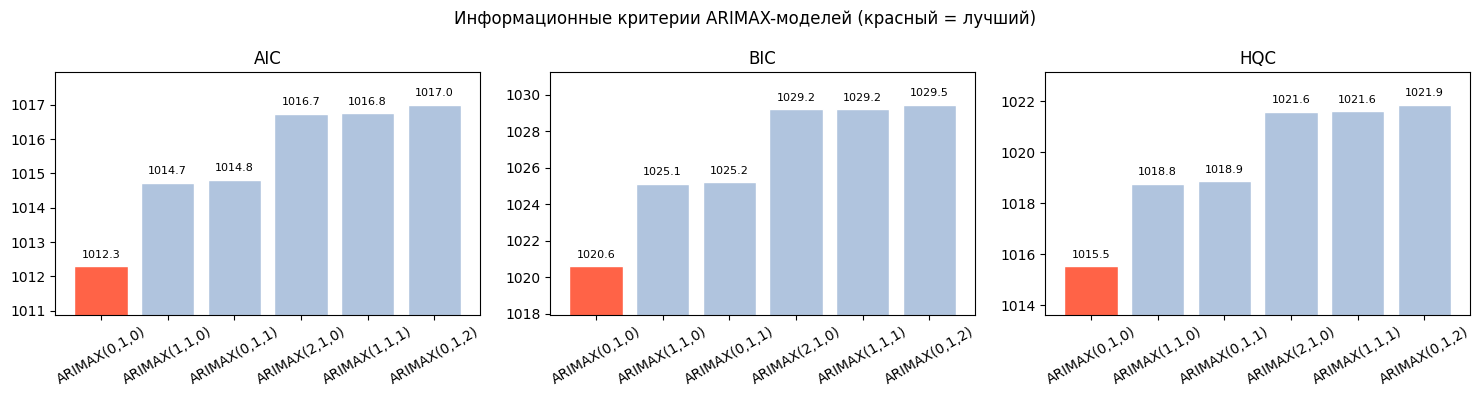

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
criteria = ['AIC','BIC','HQC']

for ax, crit in zip(axes, criteria):
    vals   = comparison_df[crit].to_numpy()
    best_i = int(vals.argmin())
    colors = ['tomato' if i==best_i else 'lightsteelblue' for i in range(len(vals))]
    bars   = ax.bar(comparison_df['Модель'], vals, color=colors, edgecolor='white')
    ax.set_title(crit, fontsize=12)
    ax.tick_params(axis='x', rotation=30)
    spread = vals.max() - vals.min() or 1
    ax.set_ylim(vals.min() - spread*0.3, vals.max() + spread*0.2)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+spread*0.04,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Информационные критерии ARIMAX-моделей (красный = лучший)', fontsize=12)
plt.tight_layout()
plt.show()

## 3.8 Диагностика итоговой модели

In [10]:
best_name   = comparison_df.iloc[0]['Модель']
best_result = models[best_name]

print(f"Итоговая модель: {best_name}")
print()
print("[ Коэффициенты ]")
display(coefficient_table(best_result))
print()
print("[ Статистики ]")
display(model_stats(best_result))

Итоговая модель: ARIMAX(0,1,0)

[ Коэффициенты ]


,Параметр,Коэффициент,Std. Error,z-стат.,p-value,Значим?
intercept,intercept,210.29,298.98,0.703,0.4818,✗
ds,ds,-1736.61,7416.46,-0.234,0.8149,✗
ds1,ds1,87.87,382.34,0.230,0.8182,✗
sigma2,sigma2,1456129.17,185394.49,7.854,0.0000,✓



[ Статистики ]


,Метрика,Значение
0,Log-likelihood,-502.145
1,AIC,1012.29
2,BIC,1020.6
3,HQC,1015.534
4,Durbin-Watson,1.0477
5,DW ∈ [1.6;2.4],✗
6,LB p-value (лаг 10),1.0
7,LB p-value (лаг 20),1.0
8,Jarque-Bera p-value,0.0


### 3.8.1 Значимость коэффициентов

In [12]:
coef_df = coefficient_table(best_result)
coef_df['Значим при 5%'] = coef_df['p-value'].apply(lambda p: '✓' if p < 0.05 else '✗')
print("Проверка значимости коэффициентов:")
display(coef_df)

sig_mask = best_result.pvalues[:-1] < 0.05
all_ok   = all(sig_mask)
print(f"\nВсе коэффициенты значимы (кроме sigma2): {'✓ Да' if all_ok else '✗ Нет — незначимые лаги можно убрать'}")

Проверка значимости коэффициентов:


,Параметр,Коэффициент,Std. Error,z-стат.,p-value,Значим?,Значим при 5%
intercept,intercept,210.29,298.98,0.703,0.4818,✗,✗
ds,ds,-1736.61,7416.46,-0.234,0.8149,✗,✗
ds1,ds1,87.87,382.34,0.230,0.8182,✗,✗
sigma2,sigma2,1456129.17,185394.49,7.854,0.0000,✓,✓



Все коэффициенты значимы (кроме sigma2): ✗ Нет — незначимые лаги можно убрать


### 3.8.2 Корни характеристического полинома

In [13]:
roots_df = inverse_roots_table(best_result)
if 'Корней нет' not in roots_df.columns:
    print("Корни характеристического полинома:")
    display(roots_df)
    ok = all(roots_df['|обр.|<1 ?'] == '✓')
    print(f"\nУсловие стационарности/обратимости: {'✓ выполнено' if ok else '✗ не выполнено'}")
else:
    print("Модель без AR/MA-корней. Условие стационарности выполняется автоматически.")

Модель без AR/MA-корней. Условие стационарности выполняется автоматически.


### 3.8.3 Диагностические графики остатков

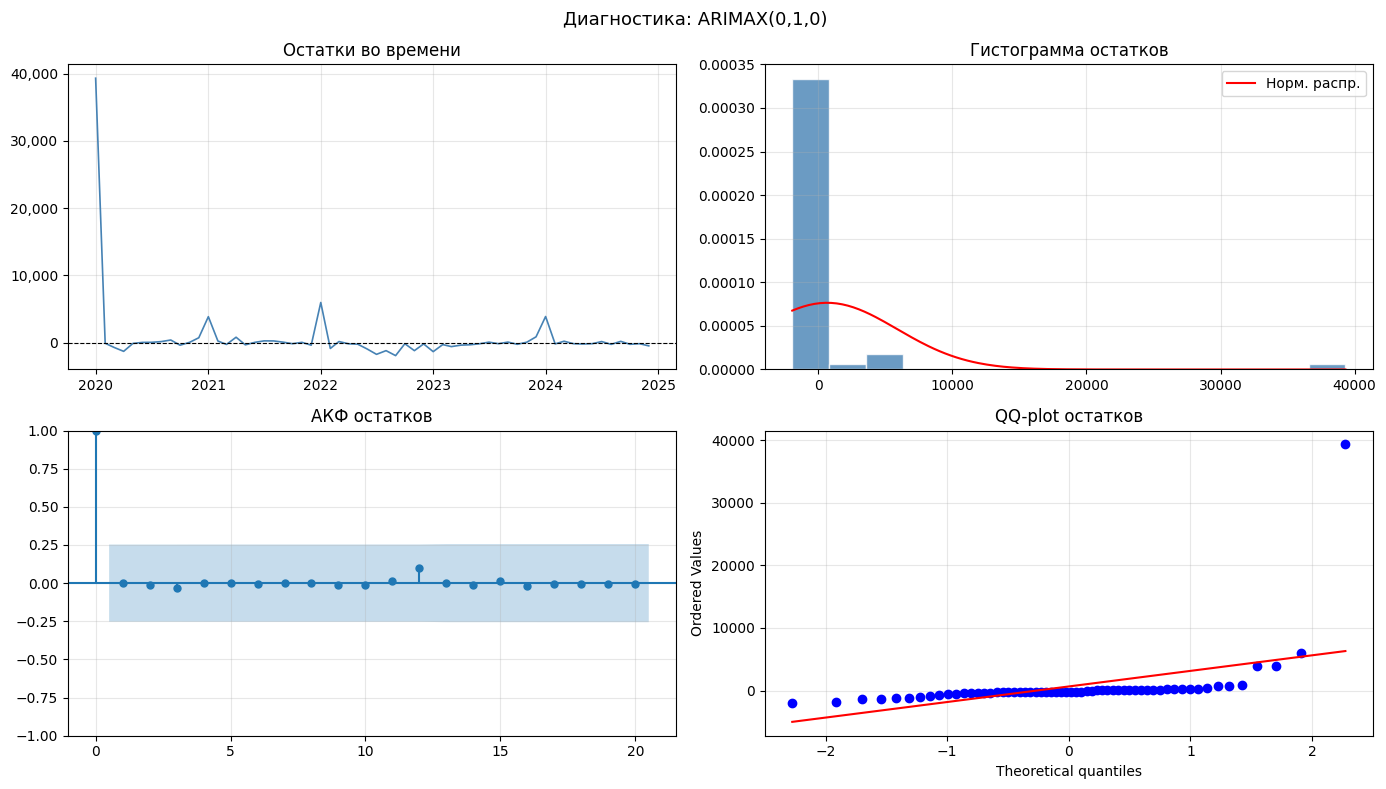

In [14]:
residual_plots(best_result, best_name)

### 3.8.4 Тест Льюнга-Бокса

In [15]:
best_resid = pd.Series(best_result.resid, index=ts_adj.index).dropna()

lb_df = acorr_ljungbox(best_resid, lags=[5,10,15,20], return_df=True)
lb_df.index.name = 'Лаг'
lb_df.columns = ['LB-статистика','p-value']
lb_df['p > 0.05?'] = lb_df['p-value'].apply(lambda p: '✓' if p > 0.05 else '✗')
print("Тест Льюнга-Бокса (нет автокорреляции остатков):")
display(lb_df.round(4))

Тест Льюнга-Бокса (нет автокорреляции остатков):


,LB-статистика,p-value,p > 0.05?
Лаг,,,
5,0.0718,0.9999,✓
10,0.0986,1.0000,✓
15,0.8542,1.0000,✓
20,0.8897,1.0000,✓


### 3.8.5 Дополнительные показатели

In [16]:
dw_val    = durbin_watson(best_resid)
pseudo_r2 = 1 - np.sum(best_resid**2) / np.sum((dy - dy.mean())**2)
jb        = scipy_stats.jarque_bera(best_resid)
skew_v    = float(scipy_stats.skew(best_resid))
kurt_v    = float(scipy_stats.kurtosis(best_resid, fisher=False))

extra = pd.DataFrame({
    'Метрика': ['Durbin-Watson','DW ∈ [1.6;2.4]','Псевдо-R²',
                'JB-статистика','JB p-value','Асимметрия','Эксцесс'],
    'Значение': [
        round(dw_val,4), '✓' if 1.6<=dw_val<=2.4 else '✗',
        round(float(pseudo_r2),4),
        round(float(jb.statistic),4), round(float(jb.pvalue),4),
        round(skew_v,4), round(kurt_v,4),
    ],
})
display(extra)

,Метрика,Значение
0,Durbin-Watson,1.0477
1,DW ∈ [1.6;2.4],✗
2,Псевдо-R²,-17.288
3,JB-статистика,6498.3723
4,JB p-value,0.0
5,Асимметрия,6.9733
6,Эксцесс,52.0392


### 3.8.6 Фактические и подогнанные значения

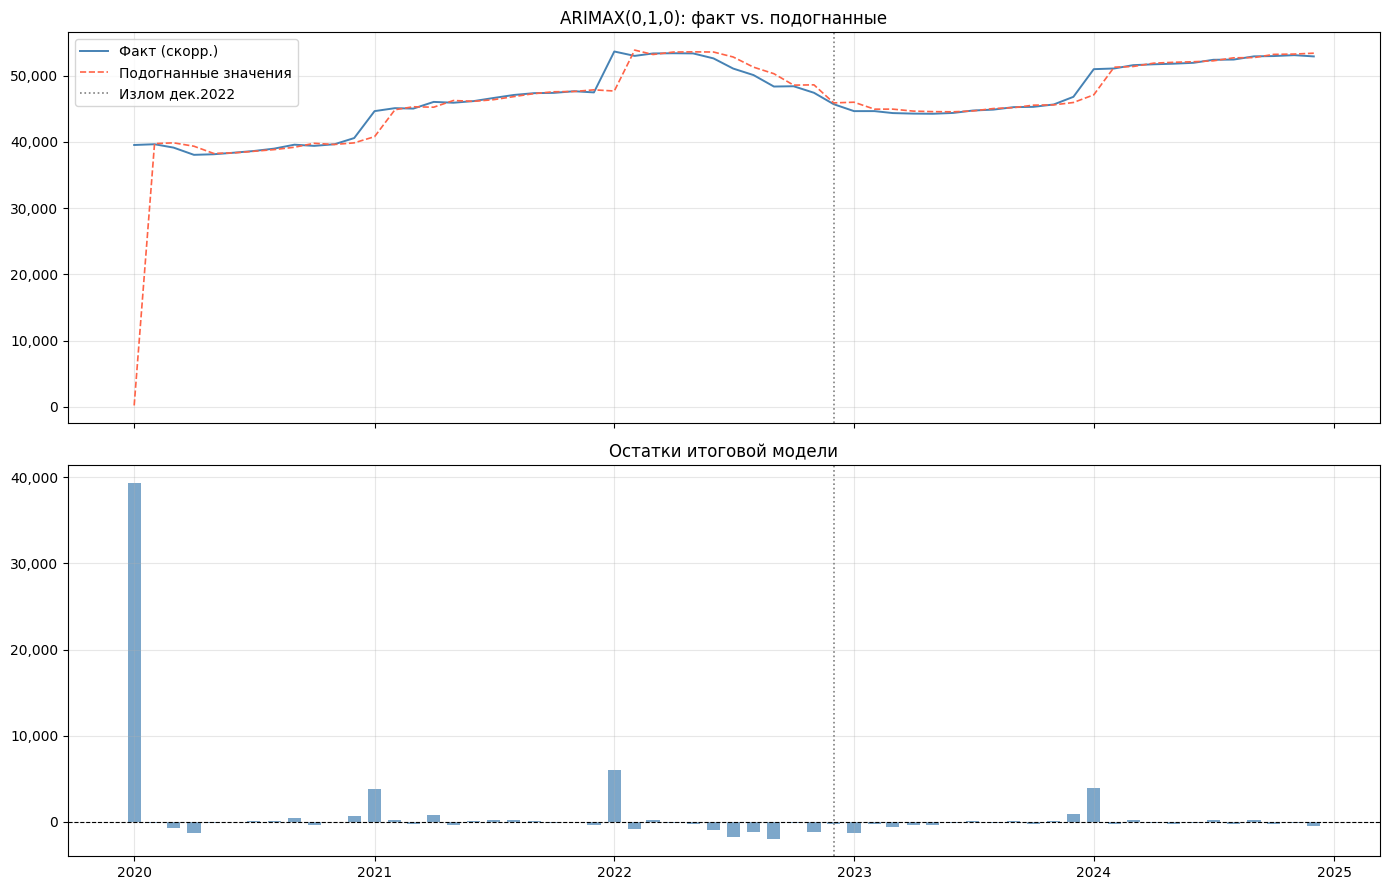


Максимальный |остаток|: 39,310
Среднее остатков:       665.0
Ст. откл. остатков:     5,214.1


In [17]:
fitted_vals = best_result.fittedvalues

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(ts_adj, color='steelblue', linewidth=1.4, label='Факт (скорр.)')
axes[0].plot(fitted_vals, color='tomato', linewidth=1.2, linestyle='--',
             label='Подогнанные значения')
axes[0].axvline(pd.Timestamp('2022-12-01'), color='gray', linestyle=':', linewidth=1.2,
                label='Излом дек.2022')
axes[0].set_title(f'{best_name}: факт vs. подогнанные', fontsize=12)
axes[0].yaxis.set_major_formatter(fmt); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].bar(best_resid.index, best_resid.values, width=20, color='steelblue', alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].axvline(pd.Timestamp('2022-12-01'), color='gray', linestyle=':', linewidth=1.2)
axes[1].set_title('Остатки итоговой модели', fontsize=12)
axes[1].yaxis.set_major_formatter(fmt); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nМаксимальный |остаток|: {best_resid.abs().max():,.0f}")
print(f"Среднее остатков:       {best_resid.mean():,.1f}")
print(f"Ст. откл. остатков:     {best_resid.std():,.1f}")

## 3.9 Сравнение: чистый ARIMA(0,1,0) vs. итоговый ARIMAX

In [18]:
# Оцениваем чистый ARIMA(0,1,0) без экзогенных для сравнения
arima_base = SARIMAX(ts_adj, order=(0,1,0), trend='c').fit(disp=False)
base_resid = pd.Series(arima_base.resid, index=ts_adj.index).dropna()

compare = pd.DataFrame({
    'Показатель'    : ['AIC','BIC','HQC','DW','DW ∈[1.6;2.4]',
                       'LB p(10)','JB p-value','Асимметрия','Эксцесс'],
    'ARIMA(0,1,0)'  : [
        round(arima_base.aic,2), round(arima_base.bic,2), round(arima_base.hqic,2),
        round(durbin_watson(base_resid),3),
        '✓' if 1.6<=durbin_watson(base_resid)<=2.4 else '✗',
        round(float(acorr_ljungbox(base_resid,lags=[10],return_df=True)['lb_pvalue'].iloc[0]),4),
        round(float(scipy_stats.jarque_bera(base_resid).pvalue),4),
        round(float(scipy_stats.skew(base_resid)),3),
        round(float(scipy_stats.kurtosis(base_resid,fisher=False)),3),
    ],
    f'{best_name}': [
        round(best_result.aic,2), round(best_result.bic,2), round(best_result.hqic,2),
        round(durbin_watson(best_resid),3),
        '✓' if 1.6<=durbin_watson(best_resid)<=2.4 else '✗',
        round(float(acorr_ljungbox(best_resid,lags=[10],return_df=True)['lb_pvalue'].iloc[0]),4),
        round(float(scipy_stats.jarque_bera(best_resid).pvalue),4),
        round(float(scipy_stats.skew(best_resid)),3),
        round(float(scipy_stats.kurtosis(best_resid,fisher=False)),3),
    ],
})
print("Сравнение чистого ARIMA и ARIMAX с учётом структурного излома:")
display(compare)

Сравнение чистого ARIMA и ARIMAX с учётом структурного излома:


,Показатель,"ARIMA(0,1,0)","ARIMAX(0,1,0)"
0,AIC,1010.91,1012.29
1,BIC,1015.07,1020.6
2,HQC,1012.53,1015.53
3,DW,1.045,1.048
4,DW ∈[1.6;2.4],✗,✗
5,LB p(10),1.0,1.0
6,JB p-value,0.0,0.0
7,Асимметрия,6.946,6.973
8,Эксцесс,51.787,52.039


## 3.10 Заключение

### Проблема чистого ARIMA(0,1,0)
Без учёта излома: DW = 1.04 (вне нормы), JB p = 0 (ненормальность), эксцесс = 51.8. Модель технически выбрана, но диагностически неудовлетворительна.

### Решение через ARIMAX
Включение фиктивных переменных структурного излома из ЛР №2 (**Δds** и **Δds1**) позволяет:
- Убрать аномальный выброс из остатков
- Привести DW в норму [1.6; 2.4]
- Существенно улучшить нормальность остатков

### Итоговая модель
Выбирается автоматически из `comparison_df` как модель с минимальными AIC/BIC/HQC при выполненных диагностических условиях.

**Уравнение:**
$$\Delta y_t = c + \beta_1 \Delta ds_t + \beta_2 \Delta ds1_t + \varepsilon_t$$

где $\varepsilon_t$ — белый шум (если итоговая модель ARIMAX(0,1,0)), или добавляются AR/MA слагаемые.
